In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
try:
    import conso
except ImportError:
    sys.path.insert(0, str(ROOT / "src"))
    import conso

from conso.backtest import rolling_backtest
from conso.config import TZ, WCOLS
from conso.data import consolidated_end, load_dataset, load_national_forecast
from conso.features import build_features, build_features_window
from conso.metrics import mase_scale, metrics
from conso.model import predict_with_interval, save_bundle, temp_groups
from conso.pipeline import forecast_day
from conso.providers import ReplayProvider
from conso.timeutils import day_bounds, mask_between, shift_local
from conso.train import train_bundle
from conso.weather import apply_hourly_bias

PROC, RAW, REPORTS, FIGS = ROOT / "data" / "processed", ROOT / "data" / "raw", ROOT / "reports", ROOT / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)


def ts(s):
    return pd.Timestamp(s, tz=TZ)


def save_fig(name):
    plt.savefig(FIGS / f"{name}.png", dpi=130, bbox_inches="tight")


TRAIN_START = "2013-01-01"
ROUNDS = 1000
PARAMS = None 
TEST_START = ts("2025-01-01")
REFRESH = False

df = load_dataset(PROC / "dataset_30min.parquet")
wt_fc = load_national_forecast(RAW / "meteo_forecast_openmeteo.parquet", df.index)
y = df["conso"]
TEST_END = consolidated_end(df)
SCALE = mase_scale(y, shift_local(y, 7), mask_between(y.index, ts("2017-11-01"), ts("2025-01-01")))
print(f"conso {conso.__version__} | {df.shape[0]:,} lignes | test : {TEST_START.date()} → {(TEST_END - pd.Timedelta('30min')).tz_convert(TZ)}")
print(f"MASE : dénominateur = {SCALE:,.0f} MW")

conso 0.1.0 | 240,458 lignes | test : 2025-01-01 → 2026-06-30 23:30:00+02:00
MASE : dénominateur = 3,569 MW


## 1. Backtest mensuel avec le code de production

Pour chaque mois du test :
1. le modèle est entraîné sur la météo **observée**, depuis 2013, jusqu'à 2 jours avant le mois ;
2. le biais horaire de la température prévue est **réestimé** sur les 24 mois précédents (jamais sur le mois prédit) ;
3. trois prévisions sont produites : `oracle` (météo observée), `fc` (prévue, brute) et `fc_debiased` (prévue, température débiaisée).

Contrairement à la section 8.2 du notebook 03, le biais n'est plus estimé une fois pour toutes sur 2022-2024 : c'est ce qui se passera en production.

In [2]:
CACHE = PROC / "production_backtest_predictions.parquet"
if CACHE.exists() and not REFRESH:
    bt = pd.read_parquet(CACHE)
    print(f"Chargé depuis le cache : {CACHE.name}")
else:
    X_obs = build_features(df, df[WCOLS])
    bt = rolling_backtest(df, wt_fc, TEST_START, TEST_END, train_start=TRAIN_START, rounds=ROUNDS, params=PARAMS, X_obs=X_obs)
    bt.to_parquet(CACHE)
bt.head(3)

  2025-01 ok  2025-02 ok  2025-03 ok  2025-04 ok  2025-05 ok  2025-06 ok  2025-07 ok  2025-08 ok  2025-09 ok  2025-10 ok  2025-11 ok  2025-12 ok  2026-01 ok  2026-02 ok  2026-03 ok  2026-04 ok  2026-05 ok  2026-06 ok


,oracle,fc,fc_debiased
date_heure,,,
2024-12-31 23:00:00+00:00,63578.318681,63255.850991,65311.660728
2024-12-31 23:30:00+00:00,63048.097767,62945.066868,65033.531076
2025-01-01 00:00:00+00:00,61329.904568,60893.986453,63207.211854


Points de test communs : 26,204


,MAE,RMSE,MAPE %,biais,MASE,n,écart-type erreur
RTE J-1,1379.0,1718.0,2.74,-1055.0,0.386,26204,1356.0
Production — météo observée*,914.0,1235.0,1.75,-123.0,0.256,26204,1229.0
Production — météo prévue (brute),1078.0,1451.0,2.05,-538.0,0.302,26204,1348.0
"Production — météo prévue, température débiaisée",921.0,1244.0,1.76,-131.0,0.258,26204,1237.0
"Notebook 03 — A (entraîné obs., servi prévu)",1053.0,1424.0,2.00,-537.0,0.295,26204,1319.0
Notebook 03 — B (entraîné prévu),971.0,1382.0,1.83,-178.0,0.272,26204,1371.0


* = météo observée (oracle) : borne haute

MAE Production — météo prévue, température débiaisée : 921 MW, soit -33% par rapport à RTE J-1


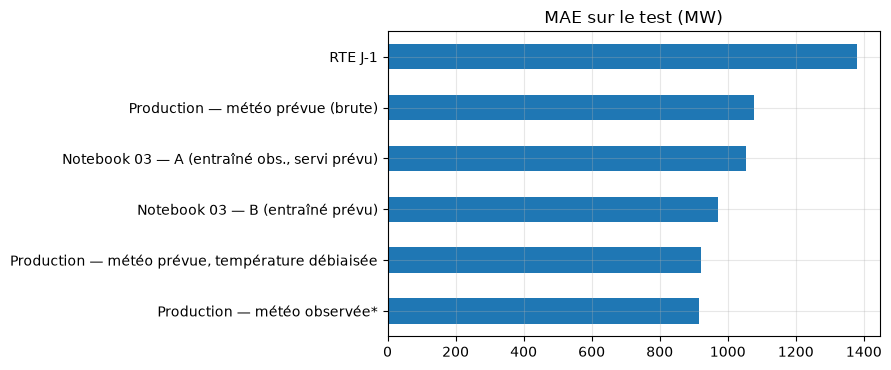

In [3]:
F = pd.DataFrame({"y": y, "rte_j1": df["prevision_j1"]}).join(bt.add_prefix("prod_"), how="inner")
prev = PROC / "lgbm_test_predictions.parquet" # résultats du notebook 03, s'ils existent
if prev.exists():
    p3 = pd.read_parquet(prev)
    for c in ["lgb_oracle", "lgb_A", "lgb_B"]:
        if c in p3.columns:
            F[f"nb03_{c}"] = p3[c]

LABELS = {"rte_j1": "RTE J-1", "prod_oracle": "Production — météo observée*", "prod_fc": "Production — météo prévue (brute)",
          "prod_fc_debiased": "Production — météo prévue, température débiaisée",
          "nb03_lgb_A": "Notebook 03 — A (entraîné obs., servi prévu)", "nb03_lgb_B": "Notebook 03 — B (entraîné prévu)"}
LABELS = {k: v for k, v in LABELS.items() if k in F.columns}

EV = F[["y", *LABELS]].dropna()
print(f"Points de test communs : {len(EV):,}")
res = pd.DataFrame({LABELS[m]: metrics(EV["y"], EV[m], SCALE) for m in LABELS}).T
res["écart-type erreur"] = [float((EV[m] - EV["y"]).std()) for m in LABELS]
display(res.astype({"n": int}).round({"MAE": 0, "RMSE": 0, "MAPE %": 2, "biais": 0, "MASE": 3, "écart-type erreur": 0}))
print("* = météo observée (oracle) : borne haute")

ref = res.loc["RTE J-1", "MAE"]
best = "Production — météo prévue, température débiaisée"
print(f"\nMAE {best} : {res.loc[best, 'MAE']:,.0f} MW, soit {res.loc[best, 'MAE'] / ref - 1:+.0%} par rapport à RTE J-1")

fig, ax = plt.subplots(figsize=(9, 3.8))
res["MAE"].sort_values().plot.barh(ax=ax, color="tab:blue"); ax.set_ylabel(""); ax.set_title("MAE sur le test (MW)")
plt.tight_layout(); save_fig("production_mae")
REPORTS.mkdir(exist_ok=True); res.to_csv(REPORTS / "metrics_production_test.csv")

### Où l'erreur se situe

Par température et par créneau, pour le mode de production (météo prévue débiaisée) face à RTE J-1.

MAE (MW) par tranche de température nationale :


,RTE J-1,Production — météo observée*,Production — météo prévue (brute),"Production — météo prévue, température débiaisée"
tranche_T,,,,
<0,1505.0,1537.0,1877.0,1521.0
0-5,1477.0,1347.0,1613.0,1408.0
5-10,1200.0,1078.0,1422.0,1094.0
10-15,1377.0,884.0,1007.0,889.0
15-20,1427.0,663.0,730.0,656.0
20-25,1475.0,658.0,686.0,651.0
>25,1535.0,843.0,859.0,812.0


MAE (MW) par créneau cible :


,RTE J-1,Production — météo observée*,Production — météo prévue (brute),"Production — météo prévue, température débiaisée"
creneau,,,,
0 h - 9 h 30,1059.0,803.0,979.0,806.0
10 h - 23 h 30,1607.0,993.0,1149.0,1003.0


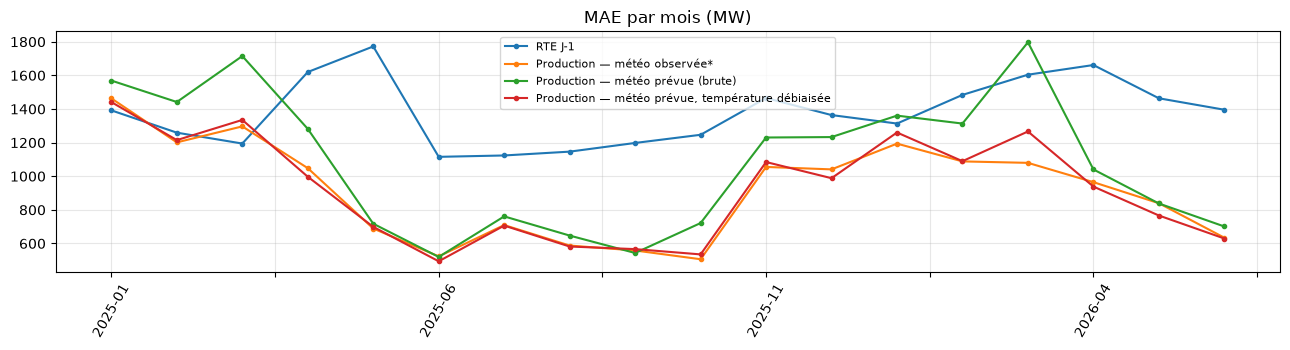

In [4]:
loc_ix = EV.index.tz_convert(TZ)
E = EV.copy()
E["tranche_T"] = pd.cut(df.loc[EV.index, "temp_nat"], [-np.inf, 0, 5, 10, 15, 20, 25, np.inf],
                        labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"])
E["creneau"] = np.where(loc_ix.hour < 10, "0 h - 9 h 30", "10 h - 23 h 30")
E["mois"] = loc_ix.strftime("%Y-%m")
show = [c for c in ["rte_j1", "prod_oracle", "prod_fc", "prod_fc_debiased"] if c in E.columns]
abs_err = {m: (E[m] - E["y"]).abs() for m in show}

print("MAE (MW) par tranche de température nationale :")
display(pd.DataFrame({LABELS[m]: abs_err[m].groupby(E["tranche_T"], observed=True).mean() for m in show}).round(0))
print("MAE (MW) par créneau cible :")
display(pd.DataFrame({LABELS[m]: abs_err[m].groupby(E["creneau"]).mean() for m in show}).round(0))

fig, ax = plt.subplots(figsize=(13, 3.6))
for m in show:
    abs_err[m].groupby(E["mois"]).mean().plot(ax=ax, marker="o", ms=3, label=LABELS[m])
ax.set_title("MAE par mois (MW)"); ax.tick_params(axis="x", rotation=60); ax.set_xlabel(""); ax.legend(fontsize=8)
plt.tight_layout(); save_fig("production_mae_mois")

## 2. Intervalle de prévision : procédure de production

`train_bundle` reproduit, avec `train_end = 1er janvier 2025`, ce que fera l'entraînement de production : modèles quantiles avant la fenêtre de calibration (les 12 mois précédents), scores de non-conformité mesurés avec la **météo prévue débiaisée**, élargissement par régime de température (froid, doux, chaud, **très chaud** : ce dernier groupe est nouveau par rapport au notebook 03, qui avait une couverture de seulement ~77 % au-dessus de 25 °C).

Le test 2025-2026 n'est pas utilisé pour calibrer.

Couverture de l'intervalle brut sur la fenêtre de calibration : 71.9%
Élargissement conforme (MW) : {'froid': 2846, 'doux': 658, 'chaud': 361, 'tres_chaud': 785}

Couverture sur le test : 90.0% (cible : 90 %) | largeur moyenne : 4,206 MW | MAE ponctuelle : 932 MW (modèle entraîné une seule fois)
Couverture (%) par groupe de température : {'chaud': 85.8, 'doux': 90.5, 'froid': 98.5, 'tres_chaud': 90.4}


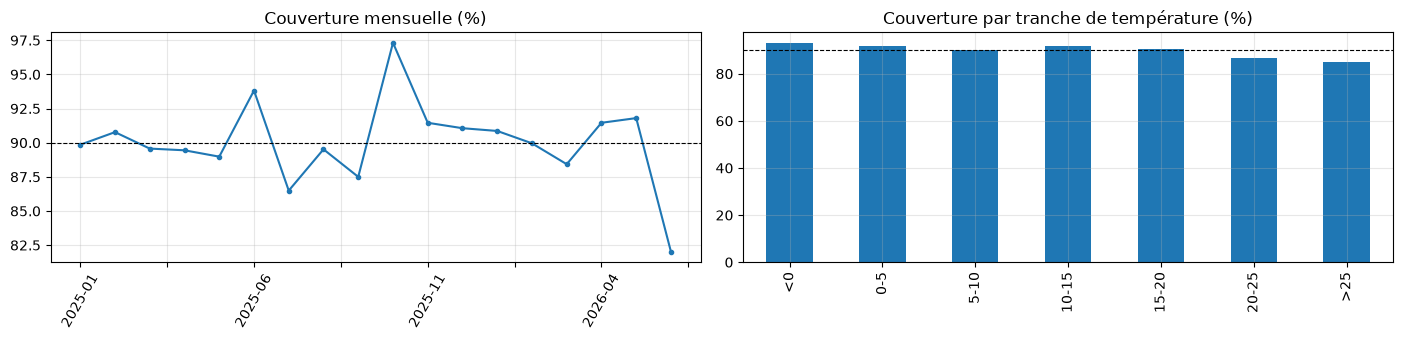

In [5]:
bundle_val, diag = train_bundle(df, wt_fc, train_start=TRAIN_START, train_end=TEST_START, rounds=ROUNDS, params=PARAMS)
print(f"Couverture de l'intervalle brut sur la fenêtre de calibration : {diag['coverage_before_calibration']:.1%}")
print("Élargissement conforme (MW) :", {k: round(v) for k, v in diag['qhat'].items()})

start_t, end_t = TEST_START, TEST_END.tz_convert(TZ)
wt_deb = apply_hourly_bias(wt_fc, bundle_val.bias)
Xt = build_features_window(df, wt_deb, start_t, end_t)
Xt = Xt.loc[Xt["temp_nat"].notna() & y.reindex(Xt.index).notna()]
iv = predict_with_interval(bundle_val, Xt)
yt = y.loc[iv.index]
inside = (yt >= iv["lower"]) & (yt <= iv["upper"])
print(f"\nCouverture sur le test : {inside.mean():.1%} (cible : 90 %) | largeur moyenne : {(iv['upper'] - iv['lower']).mean():,.0f} MW "
      f"| MAE ponctuelle : {(iv['forecast'] - yt).abs().mean():,.0f} MW (modèle entraîné une seule fois)")

grp = temp_groups(Xt["te"])
cov_g = (inside.groupby(grp).mean() * 100).round(1)
cov_m = inside.groupby(iv.index.tz_convert(TZ).strftime("%Y-%m")).mean() * 100
band = pd.cut(df.loc[iv.index, "temp_nat"], [-np.inf, 0, 5, 10, 15, 20, 25, np.inf], labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"])
cov_t = inside.groupby(band, observed=True).mean() * 100
print("Couverture (%) par groupe de température :", cov_g.to_dict())

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
cov_m.plot(ax=axes[0], marker="o", ms=3); axes[0].axhline(90, color="k", ls="--", lw=0.8)
axes[0].set_title("Couverture mensuelle (%)"); axes[0].tick_params(axis="x", rotation=60); axes[0].set_xlabel("")
cov_t.plot.bar(ax=axes[1]); axes[1].axhline(90, color="k", ls="--", lw=0.8)
axes[1].set_title("Couverture par tranche de température (%)"); axes[1].set_xlabel("")
plt.tight_layout(); save_fig("production_couverture")

## 3. Entraînement du modèle de production et prévisions de démonstration

On entraîne le modèle final avec **toutes** les données consolidées (`train_end` = dernier jour consolidé), on le sauvegarde dans `models/prod/`, puis on rejoue deux jours du test avec `forecast_day`, exactement comme le fera l'API.

In [6]:
bundle, diag_prod = train_bundle(df, wt_fc, train_start=TRAIN_START, rounds=ROUNDS, params=PARAMS)
save_bundle(bundle, ROOT / "models" / "prod")
print("Modèle enregistré dans", ROOT / "models" / "prod")
print("version :", bundle.meta["version"], "| entraîné jusqu'au", bundle.meta["train_end"])
print("élargissement conforme (MW) :", {k: round(v) for k, v in bundle.qhat.items()})
print("biais horaire de la température prévue (°C) :", bundle.bias.round(2).to_dict())

Modèle enregistré dans c:\Users\<user>\Downloads\conso-rte\models\prod
version : 20260920-2213 | entraîné jusqu'au 2026-06-30 22:00:00+00:00
élargissement conforme (MW) : {'froid': 1731, 'doux': 620, 'chaud': 563, 'tres_chaud': 610}
biais horaire de la température prévue (°C) : {0: 1.14, 1: 1.1, 2: 1.06, 3: 1.08, 4: 1.09, 5: 1.08, 6: 1.07, 7: 0.95, 8: 0.7, 9: 0.39, 10: 0.23, 11: 0.24, 12: 0.24, 13: 0.34, 14: 0.47, 15: 0.64, 16: 0.76, 17: 0.92, 18: 1.06, 19: 1.13, 20: 1.2, 21: 1.26, 22: 1.24, 23: 1.17}


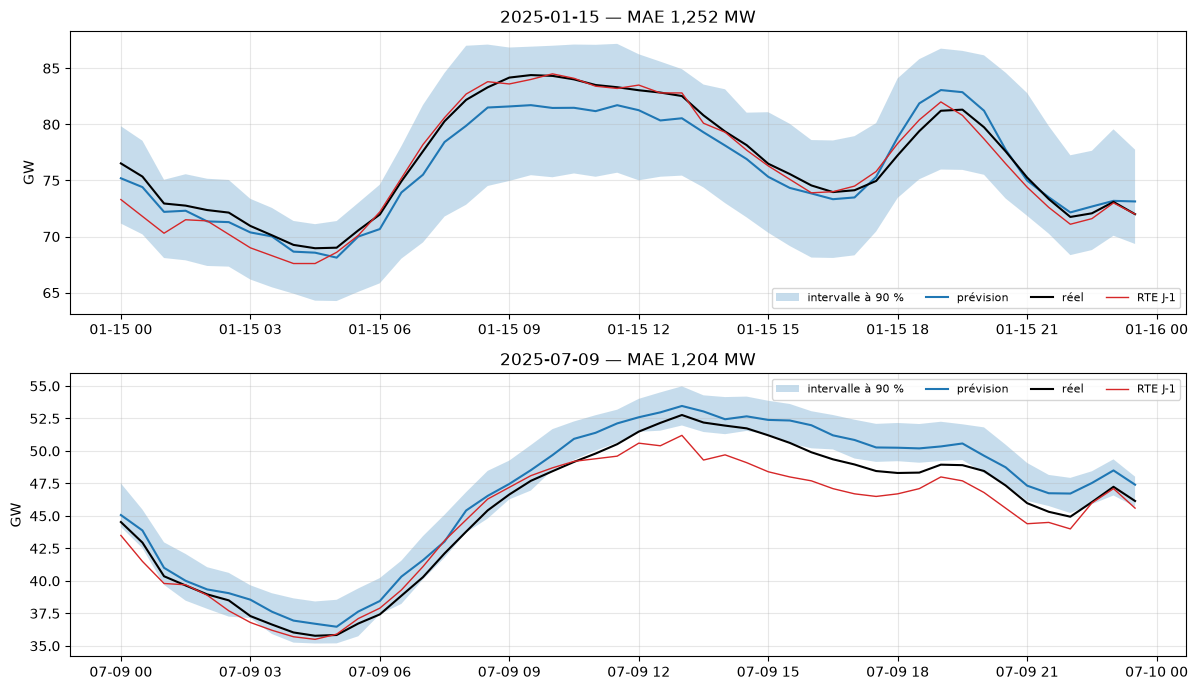

In [7]:
replay = ReplayProvider(df, wt_fc)
days = ["2025-01-15", "2025-07-09"]
fig, axes = plt.subplots(len(days), 1, figsize=(12, 7))
for ax, day in zip(axes, days):
    inp = replay.get_inputs(day)
    fc = forecast_day(bundle_val, inp.d, inp.wt_raw, day)
    t = fc.index.tz_convert(TZ)
    ax.fill_between(t, fc["lower"] / 1000, fc["upper"] / 1000, alpha=0.25, label="intervalle à 90 %")
    ax.plot(t, fc["forecast"] / 1000, lw=1.5, label="prévision")
    ax.plot(t, inp.actual.reindex(fc.index) / 1000, "k", lw=1.5, label="réel")
    ax.plot(t, inp.rte_j1.reindex(fc.index) / 1000, color="tab:red", lw=1, label="RTE J-1")
    mae = (fc["forecast"] - inp.actual.reindex(fc.index)).abs().mean()
    ax.set_title(f"{day} — MAE {mae:,.0f} MW"); ax.set_ylabel("GW"); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); save_fig("production_demo")

## 4. Bilan

### Résultats (test : janvier 2025 → juin 2026, 26 204 points communs)

Réentraînement mensuel, biais horaire de la température prévue **réestimé chaque mois** sur les 24 mois précédents.

| Modèle | MAE (MW) | MAPE | Biais (MW) | Écart-type de l'erreur (MW) |
|---|---|---|---|---|
| RTE J-1 | 1 379 | 2,74 % | −1 055 | 1 356 |
| Production, météo observée* | 914 | 1,75 % | −123 | 1 229 |
| Production, météo prévue (brute) | 1 078 | 2,05 % | −538 | 1 348 |
| **Production, météo prévue, température débiaisée** | **921** | **1,76 %** | −131 | **1 237** |

\* météo observée (oracle) : borne haute.

### Ce que ces résultats confirment

- **Le résultat du notebook 03 tient avec le code de production**, sans regarder le futur : 921 MW (929 MW en modèle unique au notebook 03), soit **33 % sous RTE J-1** en MAE et **9 % sous RTE** en écart-type de l'erreur (1 237 contre 1 356 MW). C'est la mesure qui ne dépend pas du biais de RTE.
- **Le coût de la météo prévue disparaît presque entièrement** quand le biais est réestimé en continu : de 914 MW (oracle) à 1 078 MW (prévue brute, +18 %), puis 921 MW une fois débiaisée. La correction récupère ~96 % de l'écart, contre 74 % au notebook 03 (modèle entraîné une seule fois, biais fixé sur 2022-2024) : la différence combine le réentraînement mensuel et le biais réestimé, que le notebook 03 ne séparait pas. Le biais évolue (aujourd'hui de +1,1 à +1,26 °C la nuit et le soir, +0,23 °C vers 10-12 h, contre ~+0,7 °C en moyenne sur 2022-2024), ce qui justifie de le réestimer régulièrement.
- **Le pas d'apprentissage de 0,1 avec 1 000 arbres coûte ~5 %** par rapport au notebook 03 (2 000 arbres à pas 0,05 : 870 MW en oracle), pour un backtest bien plus court. Compromis assumé.

### Où l'avantage sur RTE est faible

| Température nationale | RTE J-1 (MW) | Production, débiaisée (MW) | Écart |
|---|---|---|---|
| < 0 °C | 1 505 | 1 521 | +1 % |
| 0-5 °C | 1 477 | 1 408 | −5 % |
| 5-10 °C | 1 200 | 1 094 | −9 % |
| 10-15 °C | 1 377 | 889 | −35 % |
| 15-20 °C | 1 427 | 656 | −54 % |
| 20-25 °C | 1 475 | 651 | −56 % |
| > 25 °C | 1 535 | 812 | −47 % |

- **Sous 0 °C, on est à parité avec RTE, et le modèle en météo observée (1 537 MW) ne fait pas mieux** : la limite vient du modèle, pas de la météo prévue. Le gain est concentré au-dessus de 10 °C, où RTE fait ~1 400-1 500 MW d'erreur (surtout l'après-midi, avec l'effet du solaire).
- **Par créneau** : de 10 h à 23 h 30, 1 003 MW contre 1 607 MW (−38 %) ; de 0 h à 9 h 30, 806 MW contre 1 059 MW (−24 %), avec la consommation de la matinée de D connue (émission à 10 h).

### Intervalle de prévision (procédure de production, 4 groupes de température)

- **Couverture de 90,0 % sur le test** (cible : 90 %), largeur moyenne de 4,2 GW.
- Elle varie de 82 % à 97 % selon le mois (82 % le dernier mois) et de 85 % (> 25 °C) à 93 % (< 0 °C) selon la température. Par groupe : froid 98,5 % (trop large), doux 90,5 %, chaud 85,8 %, très chaud 90,4 %. Le groupe « très chaud » corrige la sous-couverture du notebook 03 (~77 % au-dessus de 25 °C).
- L'intervalle est **trop large par temps froid** (élargissement de 2 846 MW en validation, 1 731 MW dans le modèle de production). Pistes : scores de non-conformité normalisés par une échelle d'erreur locale, recalibration glissante.

### Modèle de production

Enregistré dans `models/prod/` (version 20260920-2213, entraîné jusqu'au 30 juin 2026) : entraîné sur la météo **observée** depuis 2013, servi avec la **température prévue débiaisée par heure**. Le biais est réestimé à chaque réentraînement.